# Praktikum Machine Learning: Bab 1
## Konsep Dasar Machine Learning

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

*notebook ini saya kerjain di Google Colab.*


## Ringkasan Konsep

* **Definisi (Mitchell):** program komputer disebut *belajar* dari pengalaman **E** untuk tugas **T** dengan ukuran performa **P**, bila performanya di **T** yang diukur dengan **P** membaik seiring bertambahnya **E**.
* **Supervised learning:** belajar dari data berlabel, contohnya klasifikasi (dataset Iris) dan regresi.
* **Alur ML dasar:** data dimuat, dibagi menjadi train/test, model dilatih, lalu dievaluasi. Itu alur yang saya jalankan di bab ini memakai KNN.


### Sel 0 - Persiapan Awal (Khusus Google Colab)

Dataset Iris di bab ini dimuat langsung dari `sklearn.datasets.load_iris`, jadi tidak ada file yang perlu diunduh. Sel kode di bawah sengaja kosong sebagai penanda persiapan awal.


In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Dataset Iris dimuat langsung dari sklearn di Praktikum 1.2,
# jadi tidak ada file yang perlu diunduh.
_DATA = []


### Praktikum 1.1 - Persiapan Library (Modul Bab 1, bagian 1.10)

Di bagian ini saya memuat semua library yang dipakai sepanjang bab ini.


In [2]:
# Menjalankan di Google Colab / Jupyter Notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Library berhasil dimuat.")


Library berhasil dimuat.


**Penjelasan output:** tidak ada error `ModuleNotFoundError`, artinya `pandas`, `numpy`, `matplotlib`, dan `scikit-learn` sudah terpasang dan siap dipakai. Dari `sklearn` saya mengambil `load_iris` (dataset), `train_test_split` (membagi data), `KNeighborsClassifier` (model), dan `accuracy_score` (metrik evaluasi).


### Praktikum 1.2 - Memuat Dataset Iris (Modul Bab 1, bagian 1.10)

Di bagian ini saya memuat dataset Iris langsung dari `sklearn` dan menambah kolom nama spesies supaya gampang dibaca.


In [3]:
iris = load_iris(as_frame=True)
df = iris.frame
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))

print("Ukuran dataset:", df.shape)
df.head()


Ukuran dataset: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


**Penjelasan output:** ukuran dataset **(150, 6)**: 150 baris data dan 6 kolom (4 fitur pengukuran ditambah kolom `target` dan `target_name`). Kolom `target` berisi angka 0, 1, 2 yang dipetakan ke tiga spesies: *setosa*, *versicolor*, *virginica*. Lima baris pertama menunjukkan semua fitur sudah terisi angka, tidak ada yang kosong.


### Praktikum 1.3 - Eksplorasi Awal Data (Modul Bab 1, bagian 1.10)

Di bagian ini saya mengecek struktur data dan jumlah data per kelas, lalu memisahkan fitur (X) dan label (y).


In [4]:
print(df.info())
print("\nJumlah data per kelas:")
print(df['target_name'].value_counts())

X = df[iris.feature_names]
y = df['target']


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB
None

Jumlah data per kelas:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


**Penjelasan output:**
* `df.info()` menunjukkan 150 entri dan 6 kolom, semuanya bertipe numerik kecuali `target_name` (object). Tidak ada nilai yang hilang.
* `value_counts()` menunjukkan tiap kelas berisi **50 data**, jadi dataset ini seimbang.
* `X` berisi 4 kolom fitur pengukuran, sedangkan `y` berisi kolom `target` sebagai label yang akan diprediksi.


### Praktikum 1.4 - Split Data dan Training KNN (Modul Bab 1, bagian 1.10)

Di bagian ini saya membagi data menjadi latih dan uji, lalu melatih model KNN dengan k=3.


In [5]:
X_train,X_test,y_train,y_test = train_test_split( X,y,
    test_size=0.2,random_state=42,stratify=y )

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
print("Model berhasil dilatih pada",X_train.shape[0],
      "data latih.")


Model berhasil dilatih pada 120 data latih.


**Penjelasan output:** dari 150 data, **120 dipakai untuk latih** dan **30 untuk uji** (`test_size=0.2`). `random_state=42` membuat pembagian ini selalu sama setiap dijalankan, dan `stratify=y` menjaga proporsi tiap kelas tetap seimbang di kedua bagian. Model KNN (k=3) berhasil dilatih pada 120 data latih.


### Praktikum 1.5 - Evaluasi Model (Modul Bab 1, bagian 1.10)

Di bagian ini saya memprediksi data uji lalu mengukur akurasinya.


In [6]:
y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi model pada data uji: {akurasi:.2%}")


Akurasi model pada data uji: 100.00%


**Penjelasan output:** akurasinya **100%**, artinya dari 30 data uji semuanya diprediksi dengan benar oleh model. Ini wajar karena ketiga spesies iris memang cukup mudah dipisahkan hanya dari fitur petalnya.


### Praktikum 1.6 - Visualisasi Sebaran Data (Modul Bab 1, bagian 1.10)

Di bagian ini saya menggambar sebaran data berdasarkan panjang dan lebar petal untuk melihat pengelompokan ketiga spesies.


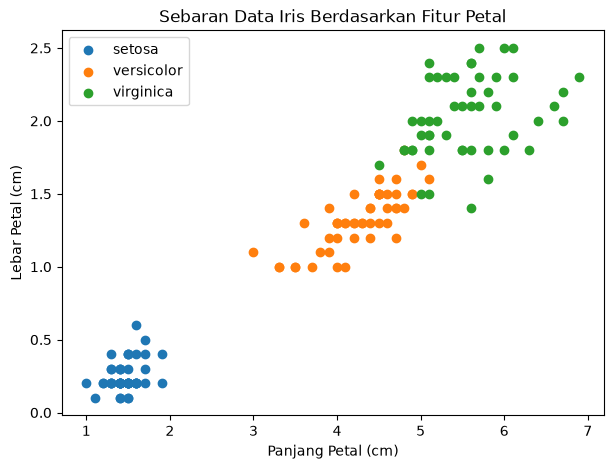

In [7]:
plt.figure(figsize=(7,5))
for target_value, target_name in enumerate(iris.target_names):
    subset = df[df['target'] == target_value]
    plt.scatter(subset['petal length (cm)'],
        subset['petal width (cm)'],label=target_name)
plt.xlabel('Panjang Petal (cm)')
plt.ylabel('Lebar Petal (cm)')
plt.title('Sebaran Data Iris Berdasarkan Fitur Petal')
plt.legend()
plt.show()


**Penjelasan output:** terlihat tiga gugus titik yang cukup terpisah: *setosa* (kiri bawah) jauh dari dua spesies lainnya, sedangkan *versicolor* dan *virginica* sedikit berdekatan tapi masih membentuk kelompok masing-masing. Ini menjelaskan kenapa KNN mudah mencapai akurasi tinggi di dataset ini.


### 1.10.3 Interpretasi (Modul Bab 1)

Dari visualisasi sebaran data, terlihat ketiga kelas bunga iris cenderung membentuk kelompok yang cukup terpisah berdasarkan fitur panjang dan lebar petal, sehingga wajar apabila model KNN memperoleh akurasi yang tinggi (umumnya di atas 90%) pada dataset ini. Latihan ini menunjukkan alur kerja ML end-to-end paling sederhana: data dimuat, dibagi menjadi train/test, model dilatih, lalu dievaluasi.


## Percobaan Mandiri

Di bagian ini saya mencoba mengubah-ubah parameter untuk melihat pengaruhnya terhadap hasil, sebagai latihan mandiri di luar kode modul.


### Percobaan Mandiri 1 - Pengaruh nilai k pada KNN

Parameter `n_neighbors` (k) menentukan berapa tetangga terdekat yang ikut voting saat memprediksi. Saya coba k = 1, 3, 5, 15, 30.


In [8]:
print(f"{'k':>4} | {'Akurasi Train':>13} | {'Akurasi Test':>12}")
print("-" * 36)
for k in [1, 3, 5, 15, 30]:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    print(f"{k:>4} | {m.score(X_train, y_train):>13.2%} | {m.score(X_test, y_test):>12.2%}")


   k | Akurasi Train | Akurasi Test
------------------------------------
   1 |       100.00% |       96.67%
   3 |        95.83% |      100.00%
   5 |        96.67% |      100.00%
  15 |        97.50% |       96.67%
  30 |        95.83% |       93.33%


**Kesimpulan:** k=1 mendapat akurasi train 100% tapi test turun (model terlalu menghafal noise), sedangkan k=30 terlalu halus sampai akurasi test ikut turun; k=3 dan k=5 memberi hasil terbaik (test 100%).


### Percobaan Mandiri 2 - Pengaruh ukuran data uji (test_size)

Saya bandingkan porsi data uji 20% dan 40% dengan k=3.


In [9]:
for ts in [0.2, 0.4]:
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=ts, random_state=42, stratify=y)
    m = KNeighborsClassifier(n_neighbors=3).fit(Xtr, ytr)
    acc = accuracy_score(yte, m.predict(Xte))
    print(f"test_size={ts}: {len(yte)} data uji, akurasi {acc:.2%}")


test_size=0.2: 30 data uji, akurasi 100.00%
test_size=0.4: 60 data uji, akurasi 96.67%


**Kesimpulan:** dengan data uji yang lebih sedikit (30 data) akurasi terlihat sempurna 100%, sedangkan dengan data uji yang lebih banyak (60 data) akurasi turun sedikit ke 96,67%, jadi porsi uji yang lebih besar memberi gambaran performa yang lebih stabil.



### Percobaan Mandiri 3 - Visualisasi decision boundary (k=3 vs k=30)

Saya menggambar batas keputusan model memakai dua fitur petal supaya efek nilai k terlihat jelas.


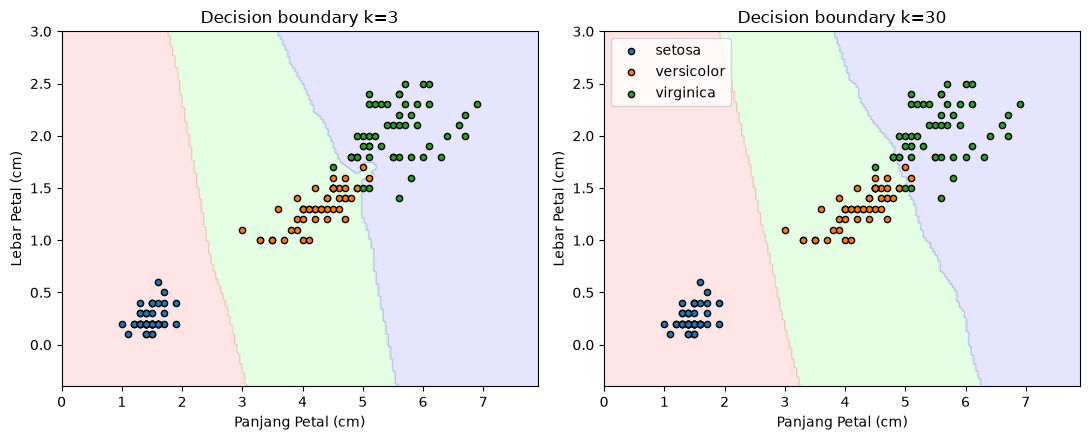

In [10]:
from matplotlib.colors import ListedColormap

X2 = df[['petal length (cm)', 'petal width (cm)']].values
y2 = y.values
xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 200),
                     np.linspace(X2[:, 1].min() - .5, X2[:, 1].max() + .5, 200))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, k in zip(axes, [3, 30]):
    m = KNeighborsClassifier(n_neighbors=k).fit(X2, y2)
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25,
                cmap=ListedColormap(['#ff9999', '#99ff99', '#9999ff']))
    for tv, tn in enumerate(iris.target_names):
        ax.scatter(X2[y2 == tv, 0], X2[y2 == tv, 1],
                   label=tn, edgecolor='k', s=20)
    ax.set_title(f'Decision boundary k={k}')
    ax.set_xlabel('Panjang Petal (cm)')
    ax.set_ylabel('Lebar Petal (cm)')
axes[1].legend()
plt.tight_layout()
plt.show()


**Kesimpulan:** di k=3 batas antar wilayah kelas tampak bergerigi mengikuti titik data, sedangkan di k=30 batasnya jauh lebih halus dan sederhana, sesuai dengan sifat k besar yang membuat model kurang sensitif terhadap noise.


## Kesimpulan Bab 1

1. Machine Learning adalah belajar pola dari data (E) untuk tugas (T) yang diukur dengan metrik (P).
2. Alur ML paling dasar: data dimuat, dibagi menjadi train/test, model dilatih, lalu dievaluasi.
3. Dataset Iris (150 data, 3 spesies) mudah dipisahkan dari fitur petalnya, sehingga KNN mencapai akurasi 100% pada data uji.
4. Nilai k dan ukuran data uji memengaruhi hasil: k terlalu kecil bikin overfitting, k terlalu besar bikin underfitting, dan data uji yang lebih banyak memberi evaluasi yang lebih stabil.
5. Dataset dimuat langsung dari `sklearn.datasets.load_iris` tanpa perlu mengunduh file apa pun.
